# تدريب نموذج التنبؤ بالأمراض من الأعراض — Disease Symptom Description Dataset

نوتبوك مستقلّ تماماً (لا يعتمد على أي كود من مشروع Healix أو DDXPlus) — يغطّي خط الأنابيب الكامل:

1. تحميل البيانات
2. تحليل استكشافي (EDA)
3. تنظيف البيانات وبناء متجه ثنائي (Binary Feature Matrix)
4. تقسيم البيانات (Train / Validation / Test) — بطريقة تمنع تسرّب الصفوف المكرّرة
5. تدريب نموذج XGBoost
6. تقييم النموذج (Accuracy, Macro-F1, Weighted-F1, Classification Report, Confusion Matrix)
7. حفظ النموذج + قائمة الميزات + Label Encoder

**قبل التشغيل:** عدّل متغيّر `DATA_DIR` بالخلية التالية ليشير لمجلد ملفات الـ CSV الخام.

In [ ]:
#

## 1. الاستيرادات

In [22]:
import os
import re
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

np.random.seed(RANDOM_SEED)


## 2. تحميل البيانات

نتوقّع بنية بيانات على شكل "قائمة أعراض" (checklist): عمود `Disease` + أعمدة `Symptom_1` إلى `Symptom_N`،
حيث كل صفّ يمثّل مرضاً واحداً وقائمة الأعراض المصاحبة له (بعض الأعمدة قد تكون فارغة NaN).

In [25]:
df_raw = pd.read_csv("C:\\healix-ai-medical-assistant\\app\\data\\raw\\disease_symptom_v1\\dataset.csv")

print("شكل البيانات الخام (rows, columns):", df_raw.shape)
df_raw.head()


شكل البيانات الخام (rows, columns): (4920, 18)


,Disease,Symptom_1,Symptom_2,Symptom_3,Symptom_4,Symptom_5,Symptom_6,Symptom_7,Symptom_8,Symptom_9,Symptom_10,Symptom_11,Symptom_12,Symptom_13,Symptom_14,Symptom_15,Symptom_16,Symptom_17
0,Fungal infection,itching,skin_rash,nodal_skin_eruptions,dischromic _patches,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Fungal infection,skin_rash,nodal_skin_eruptions,dischromic _patches,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Fungal infection,itching,nodal_skin_eruptions,dischromic _patches,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Fungal infection,itching,skin_rash,dischromic _patches,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Fungal infection,itching,skin_rash,nodal_skin_eruptions,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [26]:
symptom_columns = [c for c in df_raw.columns if c.lower().startswith("symptom")]
disease_column = "Disease" if "Disease" in df_raw.columns else df_raw.columns[0]

print("عمود المرض:", disease_column)
print("عدد أعمدة الأعراض:", len(symptom_columns))
print("أعمدة الأعراض:", symptom_columns)


عمود المرض: Disease
عدد أعمدة الأعراض: 17
أعمدة الأعراض: ['Symptom_1', 'Symptom_2', 'Symptom_3', 'Symptom_4', 'Symptom_5', 'Symptom_6', 'Symptom_7', 'Symptom_8', 'Symptom_9', 'Symptom_10', 'Symptom_11', 'Symptom_12', 'Symptom_13', 'Symptom_14', 'Symptom_15', 'Symptom_16', 'Symptom_17']


## 3. تحليل استكشافي (EDA)

In [27]:
n_diseases = df_raw[disease_column].nunique()
print(f"عدد الأمراض الفريدة: {n_diseases}")

# مفردات الأعراض الفريدة عبر كل أعمدة Symptom_N (بعد إزالة المسافات الزائدة)
def _clean_symptom(value):
    if not isinstance(value, str):
        return None
    return value.strip().lower()

raw_symptom_values = set()
for col in symptom_columns:
    raw_symptom_values.update(df_raw[col].dropna().apply(_clean_symptom).dropna().unique())

print(f"عدد الأعراض الفريدة (بعد التنظيف الأوّلي): {len(raw_symptom_values)}")


عدد الأمراض الفريدة: 41
عدد الأعراض الفريدة (بعد التنظيف الأوّلي): 131


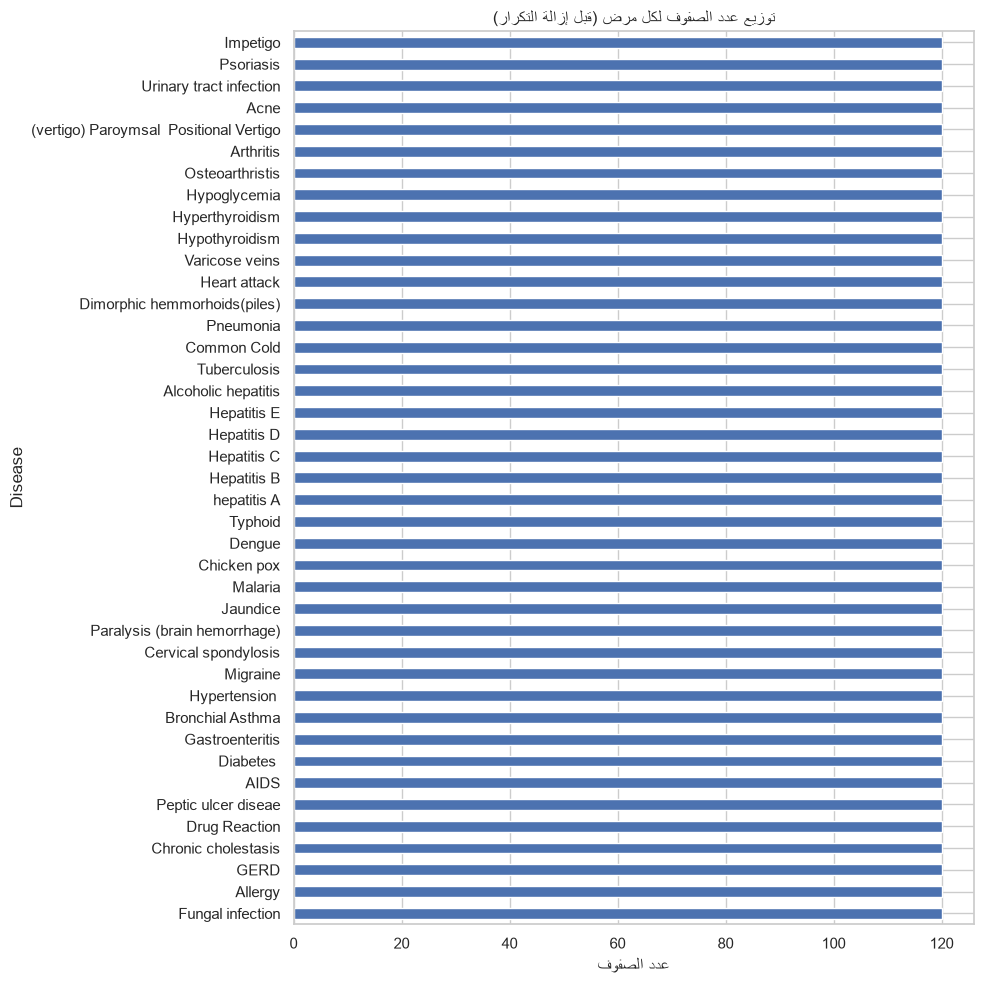

count     41.0
mean     120.0
std        0.0
min      120.0
25%      120.0
50%      120.0
75%      120.0
max      120.0
Name: count, dtype: float64

In [28]:
# توزيع عدد الصفوف لكل مرض
disease_counts = df_raw[disease_column].value_counts()

plt.figure(figsize=(10, 10))
disease_counts.plot(kind="barh")
plt.title("توزيع عدد الصفوف لكل مرض (قبل إزالة التكرار)")
plt.xlabel("عدد الصفوف")
plt.tight_layout()
plt.show()

disease_counts.describe()


In [29]:
# فحص التكرار الحرفي الكامل للصفوف — مهمّ جداً: بعض مجموعات البيانات من هذا
# النوع تحتوي نسبة تكرار عالية (نفس تركيبة الأعراض تتكرّر بصفوف متعدّدة)،
# ما يعني خطر تسرّب حقيقي بين التدريب والاختبار إن لم تتم إزالته قبل التقسيم.
n_rows_total = len(df_raw)
n_rows_unique = len(df_raw.drop_duplicates())
duplicate_rate = 1 - (n_rows_unique / n_rows_total)

print(f"إجمالي الصفوف: {n_rows_total}")
print(f"الصفوف الفريدة (بعد إزالة التكرار الحرفي الكامل): {n_rows_unique}")
print(f"نسبة التكرار: {duplicate_rate:.2%}")

if duplicate_rate > 0.3:
    print("\n⚠️ تحذير: نسبة تكرار مرتفعة — التقسيم العشوائي المباشر على الصفوف الخام "
          "سيؤدي لتسرّب بيانات بين التدريب والاختبار (نفس الصفّ يظهر بالاثنين). "
          "سنُزيل التكرار الكامل قبل أي تقسيم (انظر القسم التالي).")


إجمالي الصفوف: 4920
الصفوف الفريدة (بعد إزالة التكرار الحرفي الكامل): 304
نسبة التكرار: 93.82%

⚠️ تحذير: نسبة تكرار مرتفعة — التقسيم العشوائي المباشر على الصفوف الخام سيؤدي لتسرّب بيانات بين التدريب والاختبار (نفس الصفّ يظهر بالاثنين). سنُزيل التكرار الكامل قبل أي تقسيم (انظر القسم التالي).


## 4. تنظيف البيانات وبناء المتجه الثنائي (Binary Feature Matrix)

الخطوات:
1. تطبيع أسماء الأعراض (إزالة المسافات الزائدة، توحيد الأحرف الصغيرة، استبدال الفواصل بـ underscore).
2. إزالة الصفوف المكرّرة حرفياً (نفس المرض + نفس مجموعة الأعراض بالضبط) — **قبل** أي تقسيم.
3. بناء متجه ثنائي: عمود واحد لكل عرَض فريد (1 = موجود، 0 = غير موجود).

In [30]:
def normalize_symptom_name(raw: str) -> str:
    """توحيد اسم العرَض: إزالة المسافات، أحرف صغيرة، استبدال الفواصل بـ underscore."""
    s = raw.strip().lower()
    s = re.sub(r"[^a-z0-9]+", "_", s)
    s = re.sub(r"_+", "_", s).strip("_")
    return s


def row_symptom_set(row) -> frozenset:
    """يستخرج مجموعة الأعراض الفريدة (بعد التطبيع) لصفّ واحد."""
    symptoms = []
    for col in symptom_columns:
        value = row[col]
        if isinstance(value, str) and value.strip():
            symptoms.append(normalize_symptom_name(value))
    return frozenset(symptoms)


df = df_raw.copy()
df["_disease"] = df[disease_column].astype(str).str.strip()
df["_symptom_set"] = df.apply(row_symptom_set, axis=1)

# إزالة التكرار الحرفي الكامل (نفس المرض + نفس مجموعة الأعراض بالضبط) —
# هذه هي الخطوة الحاسمة لمنع تسرّب البيانات لاحقاً.
df_unique = df.drop_duplicates(subset=["_disease", "_symptom_set"]).reset_index(drop=True)

print(f"الصفوف قبل إزالة التكرار: {len(df)}")
print(f"الصفوف الفريدة (مرض + مجموعة أعراض) بعد الإزالة: {len(df_unique)}")

# التحقّق من أنّ كل الأمراض ما زالت مُمثَّلة بعد الإزالة
diseases_before = set(df["_disease"].unique())
diseases_after = set(df_unique["_disease"].unique())
missing_diseases = diseases_before - diseases_after
if missing_diseases:
    print(f"⚠️ تنبيه: أمراض اختفت بعد إزالة التكرار (غير متوقَّع): {missing_diseases}")
else:
    print("✓ كل الأمراض ما زالت مُمثَّلة بعد إزالة التكرار.")


الصفوف قبل إزالة التكرار: 4920
الصفوف الفريدة (مرض + مجموعة أعراض) بعد الإزالة: 304
✓ كل الأمراض ما زالت مُمثَّلة بعد إزالة التكرار.


In [31]:
# قاموس الأعراض الفريدة (المفردات) — يحدّد عدد أعمدة المتجه الثنائي وترتيبها
symptom_vocab = sorted({s for symptom_set in df_unique["_symptom_set"] for s in symptom_set})
print(f"عدد أعمدة متجه الميزات (الأعراض الفريدة): {len(symptom_vocab)}")

# بناء المصفوفة الثنائية: صفّ لكل (مرض، مجموعة أعراض) فريدة، عمود لكل عرَض
def build_binary_row(symptom_set: frozenset) -> dict:
    return {symptom: (1 if symptom in symptom_set else 0) for symptom in symptom_vocab}

binary_rows = df_unique["_symptom_set"].apply(build_binary_row).tolist()
feature_matrix = pd.DataFrame(binary_rows, columns=symptom_vocab)
feature_matrix.insert(0, "disease", df_unique["_disease"].values)

print("شكل مصفوفة الميزات الثنائية:", feature_matrix.shape)
feature_matrix.head()


عدد أعمدة متجه الميزات (الأعراض الفريدة): 131
شكل مصفوفة الميزات الثنائية: (304, 132)


,disease,abdominal_pain,abnormal_menstruation,acidity,acute_liver_failure,altered_sensorium,anxiety,back_pain,belly_pain,blackheads,...,vomiting,watering_from_eyes,weakness_in_limbs,weakness_of_one_body_side,weight_gain,weight_loss,yellow_crust_ooze,yellow_urine,yellowing_of_eyes,yellowish_skin
0,Fungal infection,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,Fungal infection,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,Fungal infection,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,Fungal infection,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,Fungal infection,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


أقلّ عدد أمثلة فريدة لمرض واحد: 5
أكبر عدد أمثلة فريدة لمرض واحد: 10
متوسّط عدد الأمثلة الفريدة لكل مرض: 7.41


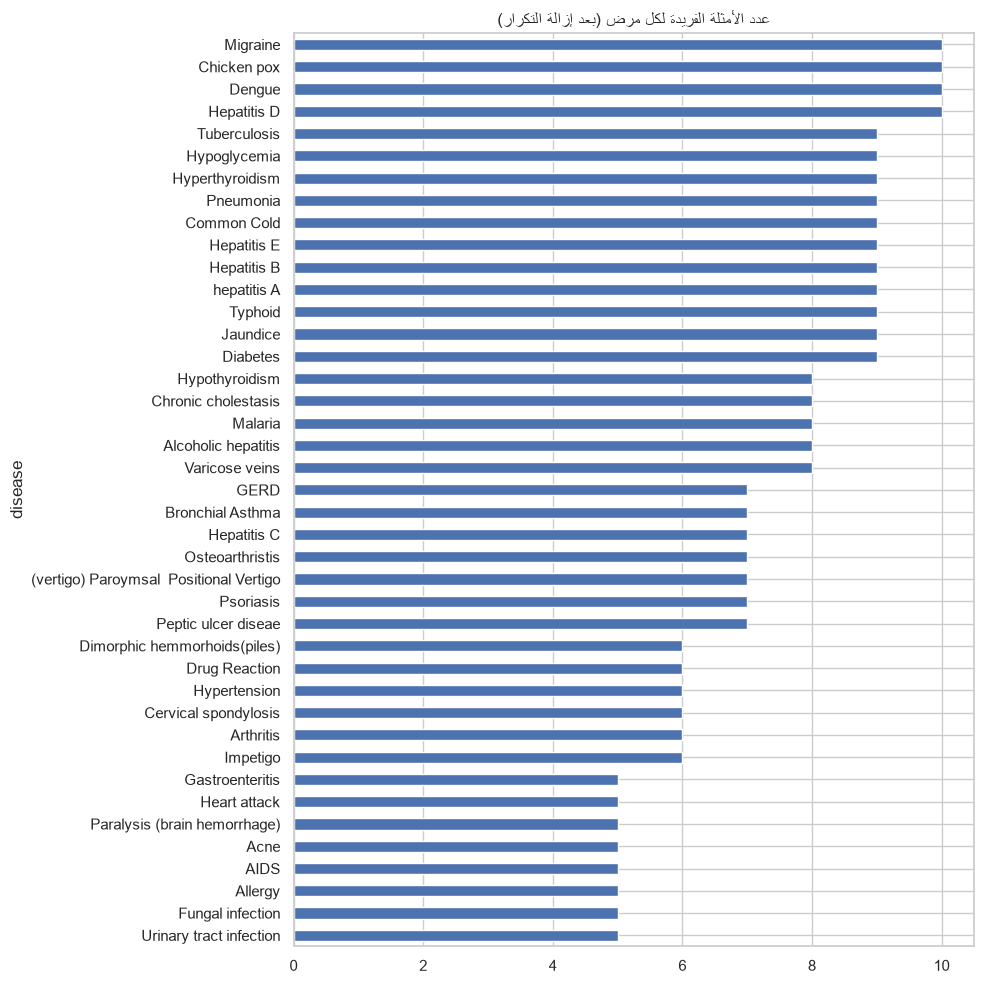

In [32]:
# توزيع عدد الأمثلة الفريدة لكل مرض بعد إزالة التكرار — يحدّد استراتيجية
# التقسيم لاحقاً (فئة بعدد أمثلة قليل جداً تحتاج معاملة خاصة).
unique_counts = feature_matrix["disease"].value_counts()
print("أقلّ عدد أمثلة فريدة لمرض واحد:", unique_counts.min())
print("أكبر عدد أمثلة فريدة لمرض واحد:", unique_counts.max())
print("متوسّط عدد الأمثلة الفريدة لكل مرض:", round(unique_counts.mean(), 2))
unique_counts.sort_values().plot(kind="barh", figsize=(10, 10), title="عدد الأمثلة الفريدة لكل مرض (بعد إزالة التكرار)")
plt.tight_layout()
plt.show()


## 5. تقسيم البيانات (Train / Validation / Test)

**مهم جداً:** التقسيم يتم على الصفوف **الفريدة فقط** (بعد إزالة التكرار بالخطوة السابقة) — لو قسّمنا
البيانات الخام مباشرة، نفس الصفّ المكرّر ممكن يظهر بالتدريب والاختبار معاً، فيعطي دقّة مضخّمة وهمية
لا تعكس قدرة النموذج الحقيقية على التعميم.

الإستراتيجية: تقسيم طبقي (stratified) على عمود `disease` — أولاً نفصل Test، ثم نقسّم الباقي إلى
Train/Validation. الفئات القليلة الأمثلة (أقل من 3) تُعامَل بحذر: قد لا تظهر بكل الأجزاء الثلاثة إذا كان
عدد أمثلتها أقل من عدد الأجزاء.

In [33]:
TEST_SIZE = 0.15
VAL_SIZE = 0.15  # نسبة من إجمالي البيانات، تُحسَب من الباقي بعد فصل Test

X_all = feature_matrix[symptom_vocab]
y_all = feature_matrix["disease"]

# فئات بعدد أمثلة قليل جداً (أقل من 3) لا يمكن تقسيمها طبقياً بأمان على 3 أجزاء —
# نطبعها بوضوح بدل تجاهلها بصمت.
class_counts = y_all.value_counts()
rare_classes = class_counts[class_counts < 3]
if len(rare_classes) > 0:
    print("⚠️ فئات بأقل من 3 أمثلة فريدة (قد لا تظهر بكل من Train/Val/Test):")
    print(rare_classes)

# الخطوة 1: فصل Test
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X_all, y_all, test_size=TEST_SIZE, stratify=y_all, random_state=RANDOM_SEED
)

# الخطوة 2: فصل Validation من الباقي
val_ratio_of_remaining = VAL_SIZE / (1 - TEST_SIZE)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=val_ratio_of_remaining,
    stratify=y_train_val, random_state=RANDOM_SEED,
)

print(f"Train: {len(X_train)} صفّاً | Validation: {len(X_val)} صفّاً | Test: {len(X_test)} صفّاً")
print(f"عدد الأمراض المُمثَّلة — Train: {y_train.nunique()} | Val: {y_val.nunique()} | Test: {y_test.nunique()}")


Train: 212 صفّاً | Validation: 46 صفّاً | Test: 46 صفّاً
عدد الأمراض المُمثَّلة — Train: 41 | Val: 41 | Test: 41


## 6. تدريب نموذج XGBoost

In [34]:
label_encoder = LabelEncoder()
label_encoder.fit(y_all)  # يشمل كل الفئات لضمان تطابق التشفير عبر كل الأجزاء

y_train_enc = label_encoder.transform(y_train)
y_val_enc = label_encoder.transform(y_val)
y_test_enc = label_encoder.transform(y_test)

model = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.1,
    subsample=0.9,
    colsample_bytree=0.8,
    objective="multi:softprob",
    eval_metric="mlogloss",
    random_state=RANDOM_SEED,
    n_jobs=-1,
)

model.fit(
    X_train, y_train_enc,
    eval_set=[(X_val, y_val_enc)],
    verbose=False,
)

print("تمّ تدريب النموذج بنجاح.")
print("عدد الميزات:", model.n_features_in_)
print("عدد الفئات:", len(label_encoder.classes_))


تمّ تدريب النموذج بنجاح.
عدد الميزات: 131
عدد الفئات: 41


## 7. تقييم النموذج

نقيّم على مجموعة **Test** المحجوزة بالكامل (لم يرها النموذج أثناء التدريب أو ضبط المعاملات).

In [35]:
y_pred_enc = model.predict(X_test)
y_pred = label_encoder.inverse_transform(y_pred_enc)
y_true = label_encoder.inverse_transform(y_test_enc)

accuracy = accuracy_score(y_test_enc, y_pred_enc)
macro_f1 = f1_score(y_test_enc, y_pred_enc, average="macro", zero_division=0)
weighted_f1 = f1_score(y_test_enc, y_pred_enc, average="weighted", zero_division=0)

print(f"Accuracy:     {accuracy:.4f}")
print(f"Macro F1:     {macro_f1:.4f}")
print(f"Weighted F1:  {weighted_f1:.4f}")


Accuracy:     0.9783
Macro F1:     0.9675
Weighted F1:  0.9710


In [36]:
# تقرير تصنيف كامل: Precision / Recall / F1 لكل فئة على حدة
report_text = classification_report(
    y_true, y_pred, zero_division=0,
)
print(report_text)

# نسخة كقاموس لحفظها لاحقاً إن رغبت
report_dict = classification_report(y_true, y_pred, zero_division=0, output_dict=True)


                                         precision    recall  f1-score   support

(vertigo) Paroymsal  Positional Vertigo       1.00      1.00      1.00         1
                                   AIDS       1.00      1.00      1.00         1
                                   Acne       1.00      1.00      1.00         1
                    Alcoholic hepatitis       1.00      1.00      1.00         1
                                Allergy       1.00      1.00      1.00         1
                              Arthritis       0.00      0.00      0.00         1
                       Bronchial Asthma       1.00      1.00      1.00         1
                   Cervical spondylosis       1.00      1.00      1.00         1
                            Chicken pox       1.00      1.00      1.00         2
                    Chronic cholestasis       1.00      1.00      1.00         1
                            Common Cold       1.00      1.00      1.00         1
                           

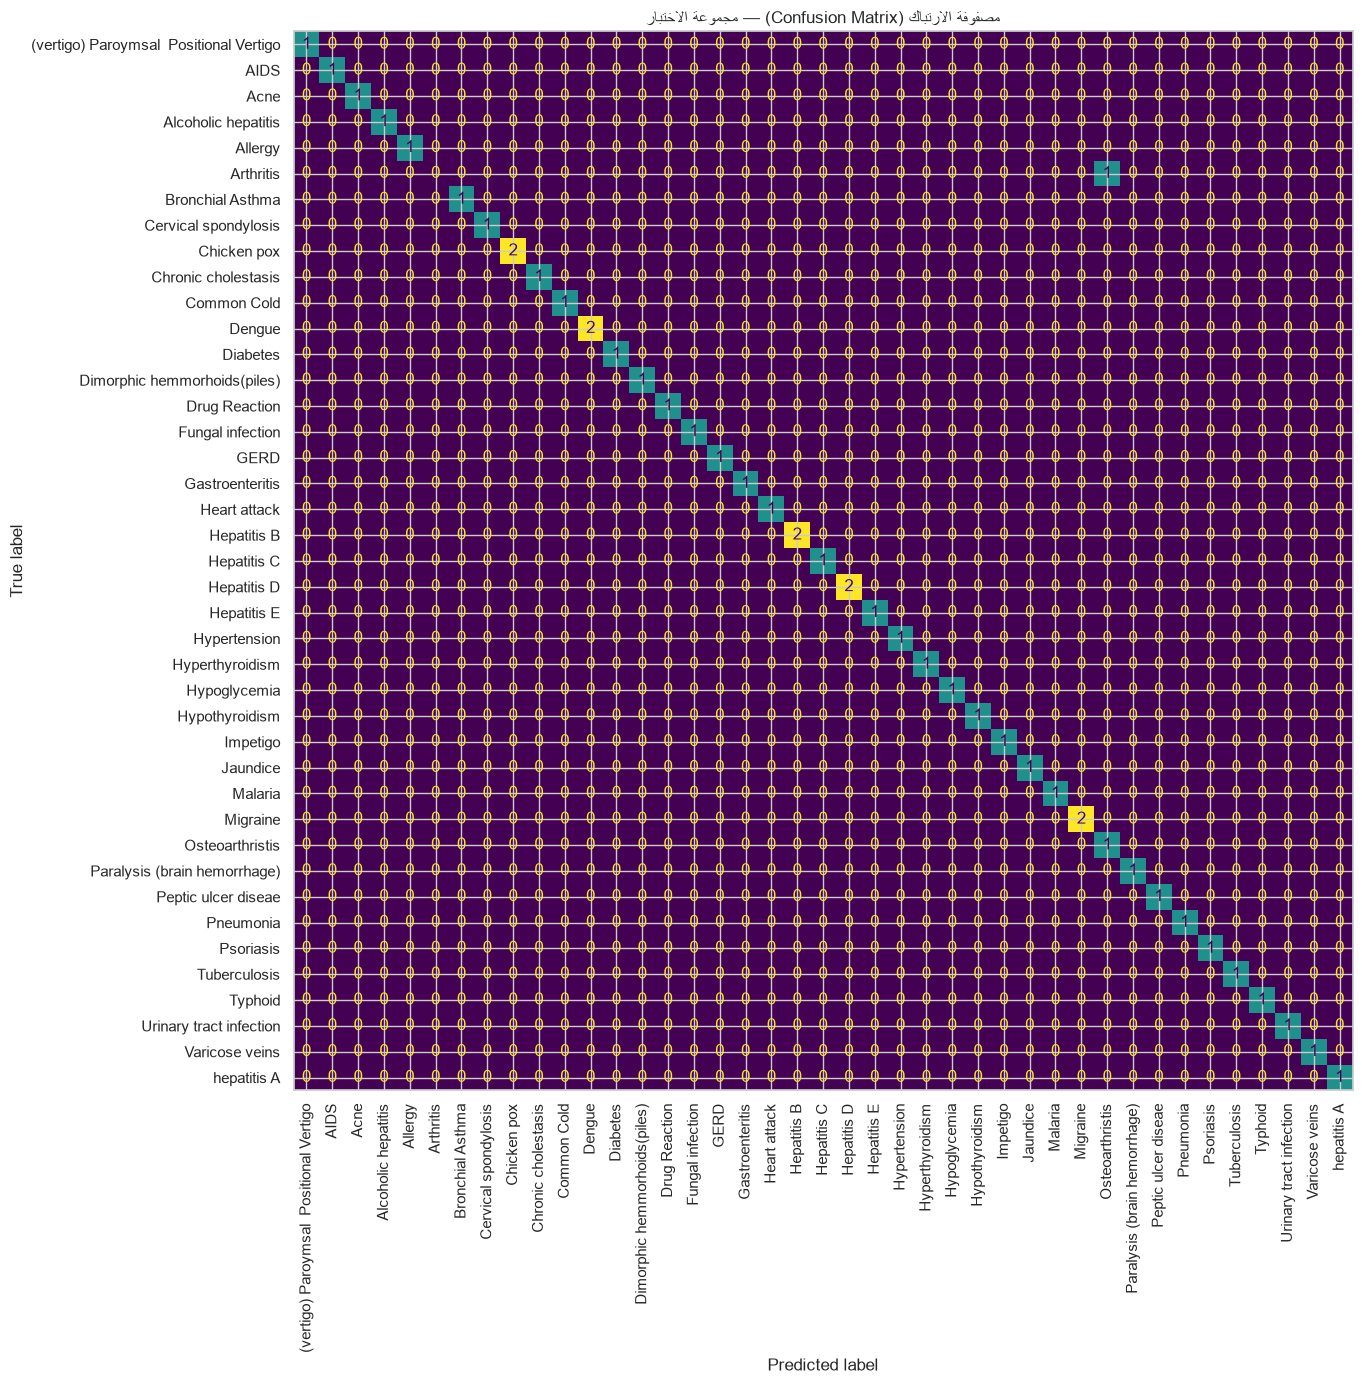

In [37]:
# مصفوفة الارتباك (Confusion Matrix) — قد تكون كبيرة بعدد الأمراض، نعرضها بحجم مناسب
fig, ax = plt.subplots(figsize=(14, 14))
ConfusionMatrixDisplay.from_predictions(
    y_true, y_pred,
    labels=label_encoder.classes_,
    xticks_rotation="vertical",
    ax=ax,
    colorbar=False,
)
plt.title("مصفوفة الارتباك (Confusion Matrix) — مجموعة الاختبار")
plt.tight_layout()
plt.show()


## 8. حفظ النموذج والملفات المرتبطة

In [38]:
os.makedirs(OUTPUT_DIR, exist_ok=True)

# 1. النموذج المدرَّب
model_path = os.path.join(OUTPUT_DIR, "xgboost_model.joblib")
joblib.dump(model, model_path)

# 2. قائمة الميزات (ترتيب أعمدة متجه الإدخال — ضروري لإعادة بناء نفس المتجه وقت الاستدلال)
feature_names_path = os.path.join(OUTPUT_DIR, "feature_names.json")
with open(feature_names_path, "w", encoding="utf-8") as f:
    json.dump(symptom_vocab, f, ensure_ascii=False, indent=2)

# 3. Label Encoder (لفكّ ترميز تنبؤات النموذج إلى أسماء أمراض)
label_encoder_path = os.path.join(OUTPUT_DIR, "label_encoder.joblib")
joblib.dump(label_encoder, label_encoder_path)

# 4. بيانات وصفية (metadata) — تلخيص الإعدادات والنتائج لإعادة الإنتاج لاحقاً
metadata = {
    "n_features": int(model.n_features_in_),
    "n_classes": int(len(label_encoder.classes_)),
    "classes": list(label_encoder.classes_),
    "train_rows": int(len(X_train)),
    "val_rows": int(len(X_val)),
    "test_rows": int(len(X_test)),
    "raw_rows_before_dedup": int(n_rows_total),
    "unique_rows_after_dedup": int(len(df_unique)),
    "test_accuracy": float(accuracy),
    "test_macro_f1": float(macro_f1),
    "test_weighted_f1": float(weighted_f1),
    "random_seed": RANDOM_SEED,
}
metadata_path = os.path.join(OUTPUT_DIR, "metadata.json")
with open(metadata_path, "w", encoding="utf-8") as f:
    json.dump(metadata, f, ensure_ascii=False, indent=2)

print("تمّ الحفظ في:", os.path.abspath(OUTPUT_DIR))
print(" -", model_path)
print(" -", feature_names_path)
print(" -", label_encoder_path)
print(" -", metadata_path)


تمّ الحفظ في: c:\healix-ai-medical-assistant\training\notebooks\model_output
 - ./model_output\xgboost_model.joblib
 - ./model_output\feature_names.json
 - ./model_output\label_encoder.joblib
 - ./model_output\metadata.json


## 9. مثال سريع لإعادة استخدام النموذج المحفوظ

توضيح كيف تُبنى عيّنة إدخال جديدة ويُستخرَج منها تنبؤ، بنفس ترتيب الأعمدة المحفوظ بـ `feature_names.json`.

In [39]:
# مثال: مريض ذكر أعراض "cough" و "headache" (استبدلها بأسماء أعمدة حقيقية من symptom_vocab)
example_symptoms = {symptom_vocab[0], symptom_vocab[1]}  # مثال توضيحي فقط

input_vector = pd.DataFrame(
    [[1 if s in example_symptoms else 0 for s in symptom_vocab]],
    columns=symptom_vocab,
)

predicted_index = model.predict(input_vector)[0]
predicted_disease = label_encoder.inverse_transform([predicted_index])[0]
predicted_proba = model.predict_proba(input_vector)[0][predicted_index]

print("الأعراض المُدخَلة:", example_symptoms)
print(f"التنبؤ: {predicted_disease} (احتمال {predicted_proba:.2%})")


الأعراض المُدخَلة: {'abnormal_menstruation', 'abdominal_pain'}
التنبؤ: Peptic ulcer diseae (احتمال 9.91%)
